In [2]:
from meteostat import Point, Daily,Stations
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
Penang  = Point(5.3000, 100.2667)
start   = datetime(2010,1,1)
end     = datetime(2025,12,31)

data = Daily(Penang, start,end)
data = data.fetch()
data.head()

In [13]:
data.to_csv("Penang_15year_weather_info.csv")

In [14]:
df =pd.read_csv(r"C:\Users\leemi\revisionsw\Portfolio\Penang_15year_weather_info.csv", low_memory = True)

In [15]:
# Filesize was a little too big, low_memory was done as an insurance.

In [16]:
df2 = df.drop(columns = ["snow","wdir","wpgt","tsun","pres"])

In [17]:
# Removing unnecessary columns(populated mostly with NaN). Pres(Sea Level Pressure) has data but it is 
# unlikely to be used.

In [18]:
df3 = df2.interpolate(limit=3)

In [19]:
df4 = df3.rename(columns={"time" : "date"})

In [20]:
df4.set_index("date",inplace= True)
df4.index = pd.to_datetime(df4.index)
df4.index

DatetimeIndex(['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04',
               '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08',
               '2010-01-09', '2010-01-10',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-20',
               '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24',
               '2025-12-25', '2025-12-26'],
              dtype='datetime64[ns]', name='date', length=5839, freq=None)

In [9]:
df4.to_parquet("15year_base.parquet")

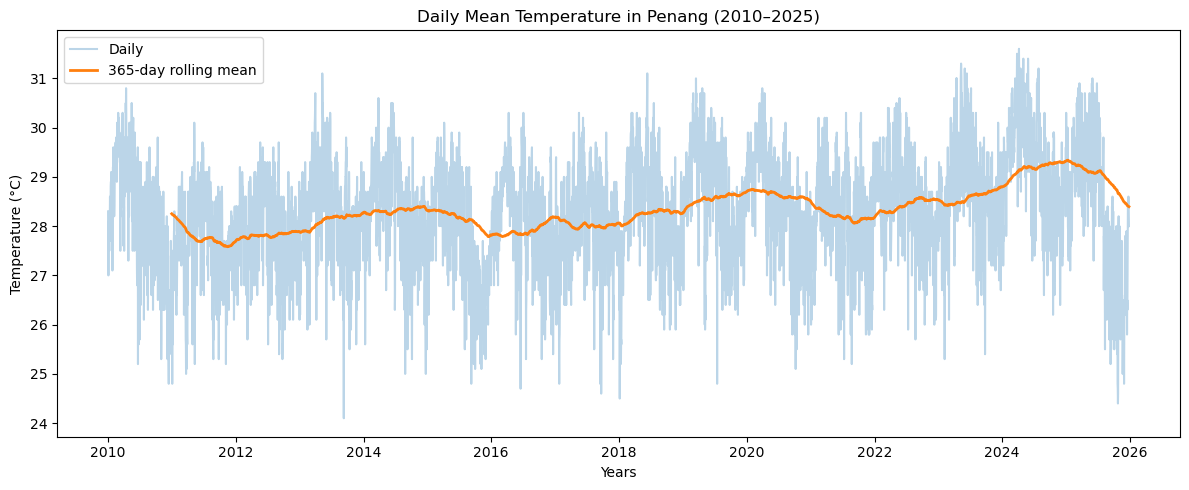

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(df4.index, df4["tavg"], alpha=0.3, label="Daily")
plt.plot(
    df4.index,
    df4["tavg"].rolling(365).mean(),
    linewidth=2,
    label="365-day rolling mean"
)

plt.title("Daily Mean Temperature in Penang (2010–2025)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Years")
plt.legend()
plt.tight_layout()
plt.show()

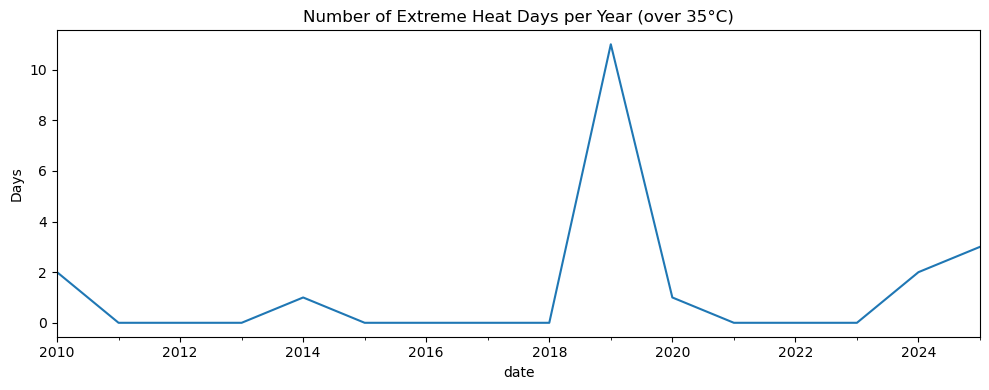

In [22]:
df4["extreme_heat"] = df4["tmax"] > 35

extreme_per_year = df4["extreme_heat"].resample("YE").sum()

plt.figure(figsize=(10, 4))
extreme_per_year.plot()

plt.title("Number of Extreme Heat Days per Year (over 35°C)")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

In [23]:
# looking at the average of days that exceed 35°C, with the exception of 2019, most of the years average around 1 to 2 days of hot days.

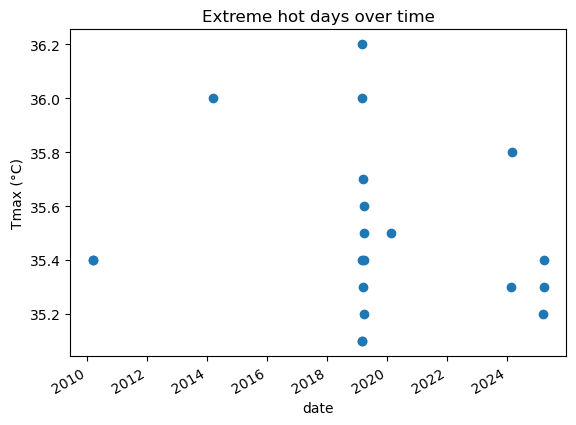

In [24]:
df4.loc[df4["tmax"] > 35, "tmax"].plot(style="o")
plt.title("Extreme hot days over time")
plt.ylabel("Tmax (°C)")
plt.show()

In [25]:
# Other than 2014 and 2019, the temperatures don't really go above to 36°C, most ly staying around the 35.5°C mark.

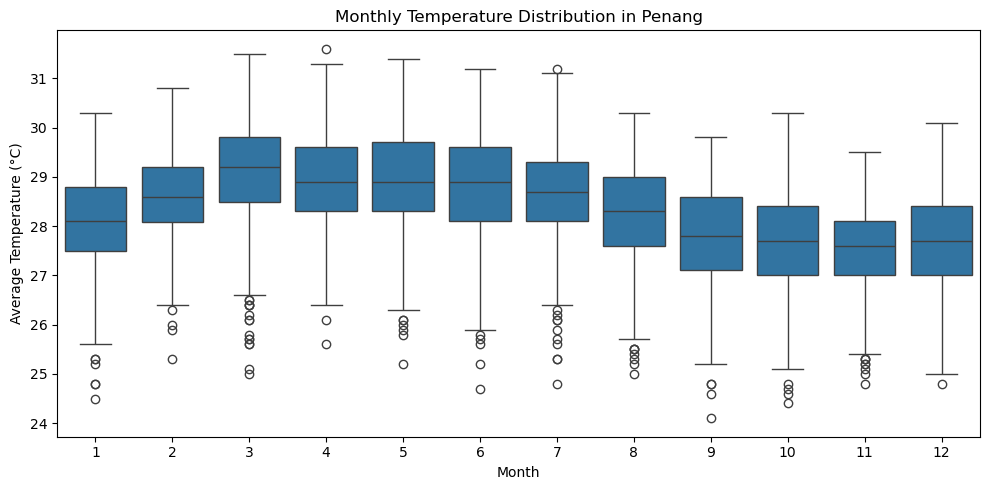

In [26]:
df4["month"] = df4.index.month
plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="tavg", data=df4)

plt.title("Monthly Temperature Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

In [27]:
# hmmm this shows the avarage temperatures of months for the past 15 years....might not be an effective way to show data, as global warming
# might change the tempereature across the years....I wonder if doing this as a line chart without categorizing them under months would show better 
# data...

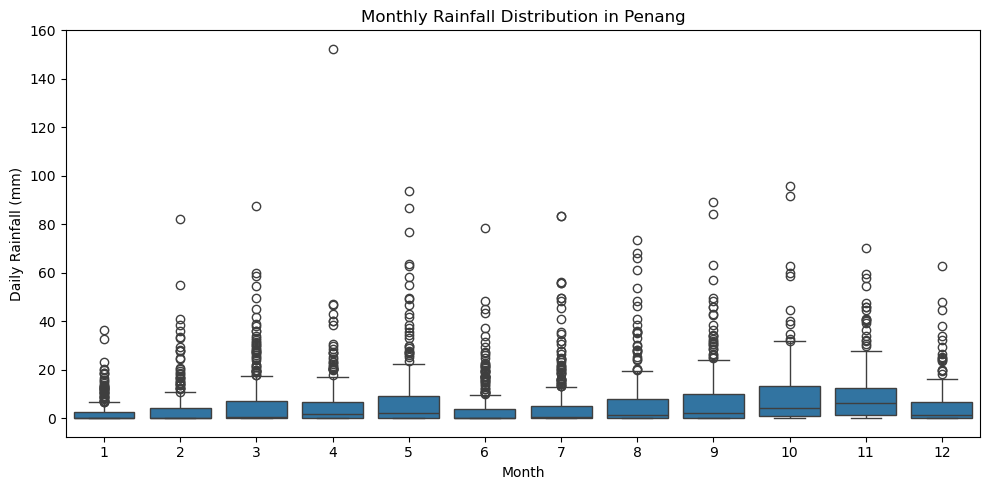

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="prcp", data=df4)

plt.title("Monthly Rainfall Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.show()

In [29]:
# apparently the monsoon season is between may to september, honestly it feels a little hard to look at the data here.....
# as a person who's not used to looking at the chart determining when the rain fall congregates to determine the monsoon season is impossible 
# I mean I could see that the overlap is particularly strong during may, june and july but march is also a strong contender?

In [38]:
df20 =pd.read_csv(r"C:\Users\leemi\revisionsw\Portfolio\monthly.csv")

In [31]:
df21=df20.drop(columns=["extreme_heat","month"])
df21.set_index("date",inplace= True)

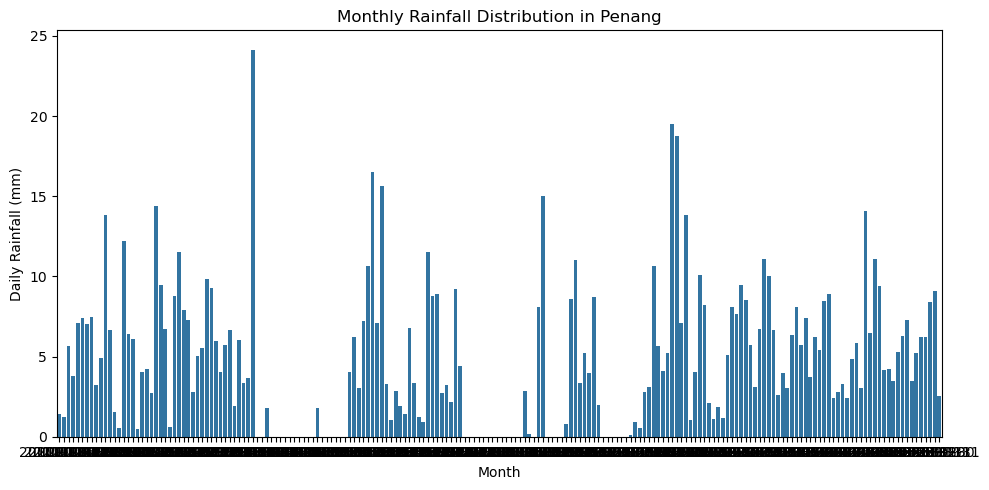

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=df21)

plt.title("Monthly Rainfall Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.show()

In [33]:
# this actually shows when the most rainfall is, but the problem is that there's way too much data,
# so clearer viewing of which particular months they are are hard....
# I'll have to check if there's other ways....

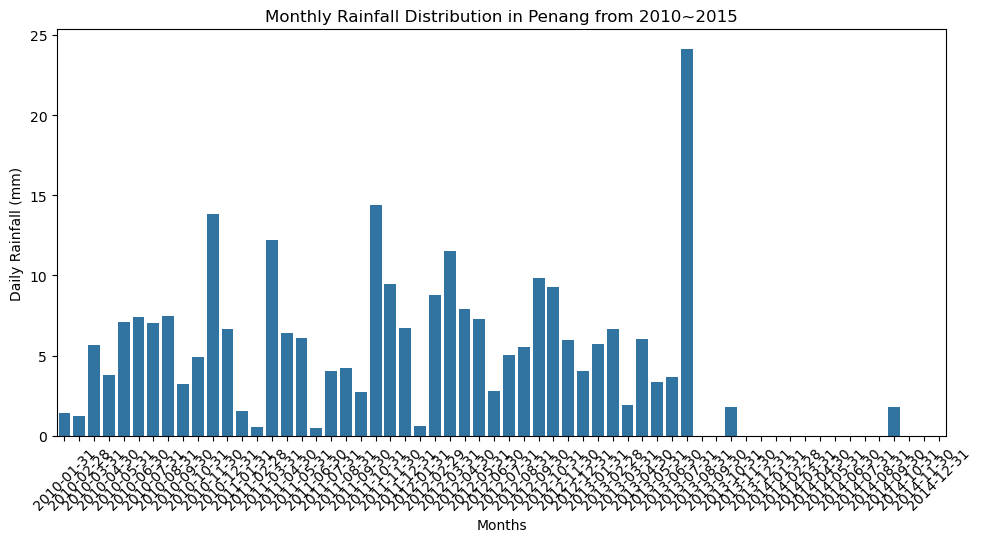

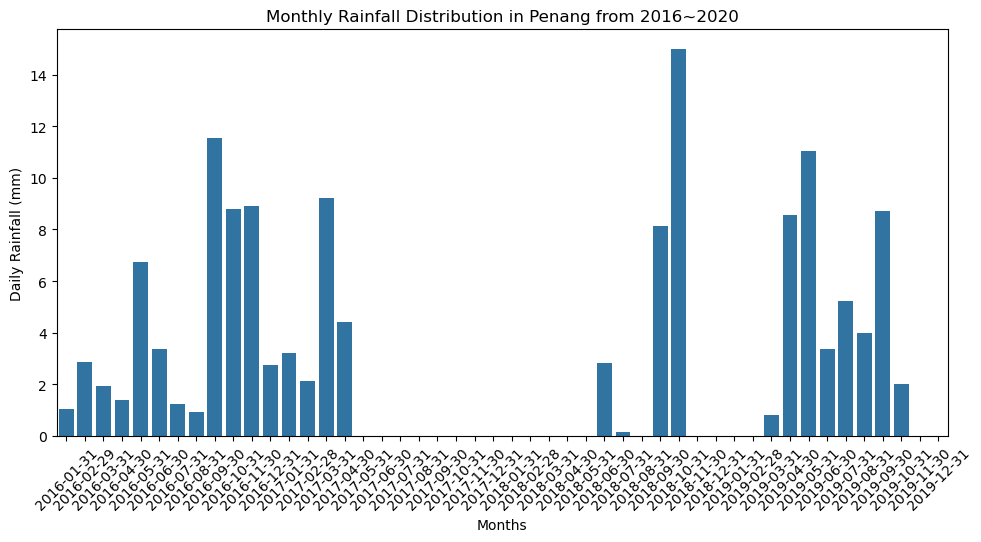

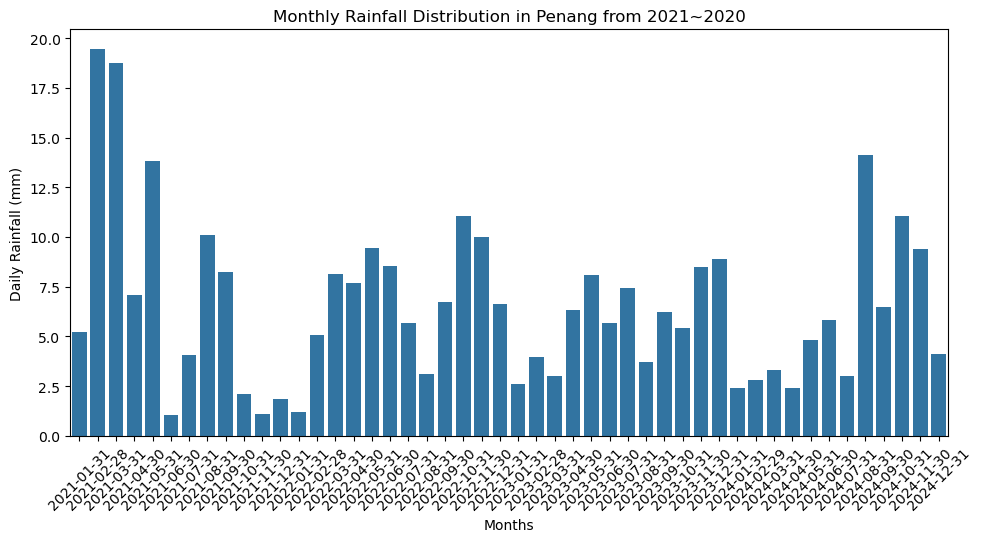

In [34]:
subset1 = df21.loc['2010':'2015']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset1)

plt.title("Monthly Rainfall Distribution in Penang from 2010~2015")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

subset2 = df21.loc['2016':'2020']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset2)

plt.title("Monthly Rainfall Distribution in Penang from 2016~2020")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

subset3 = df21.loc['2021':'2025']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset3)

plt.title("Monthly Rainfall Distribution in Penang from 2021~2020")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
# looks better.....I wonder if there's a smaller code that can achieve the same results...
# or at least change the labelling/ period of the dates..... I know 
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
# does what I want but like the graph is UGLYYY!

NameError: name 'monthly' is not defined

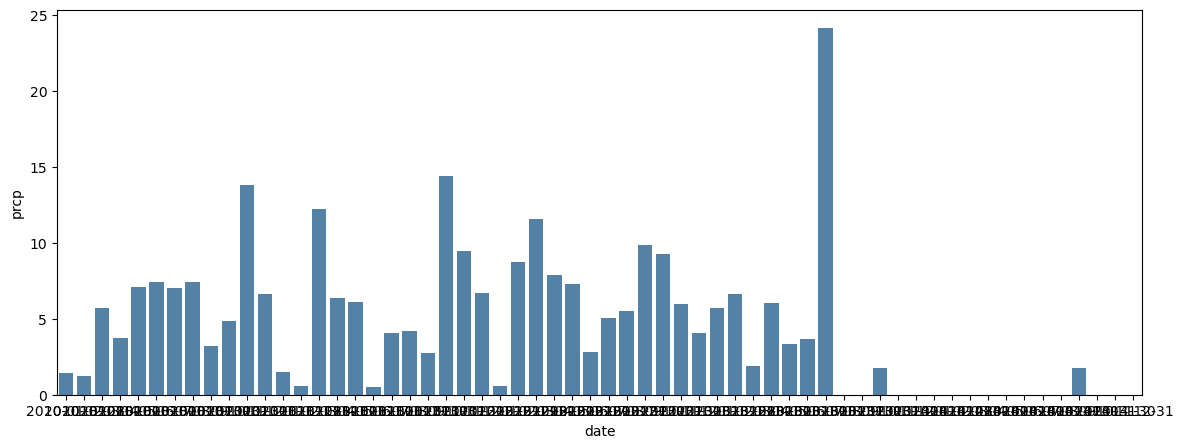

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(
    data=subset1,
    x='date',
    y='prcp',
    ax=ax,
    color='steelblue'
)
step = 3  # try 3, 4, or 6

ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(
    subset1['date'].dt.strftime('%b-%Y')[::step],
    rotation=45,
    ha='right'
)
ax.set_title("Monthly Rainfall Distribution in Penang (2010–2015)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Rainfall (mm)")

plt.tight_layout()
plt.show()


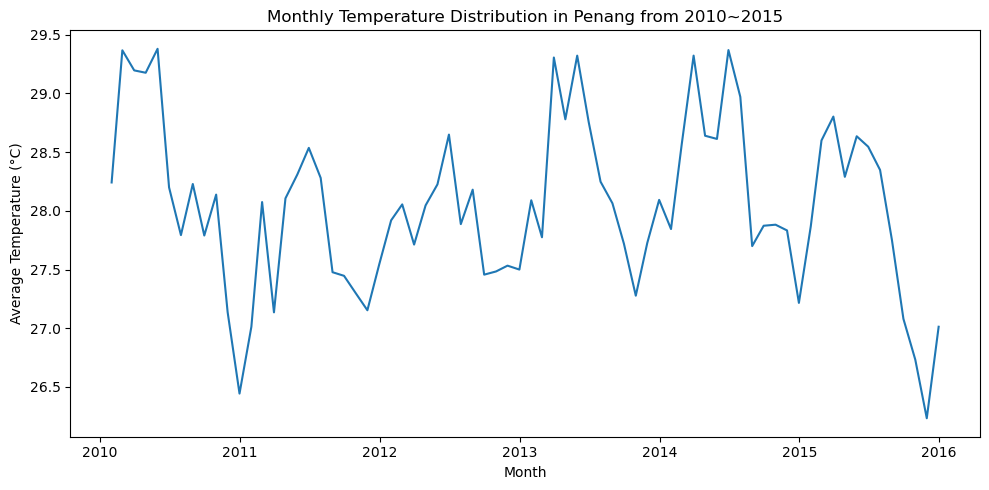

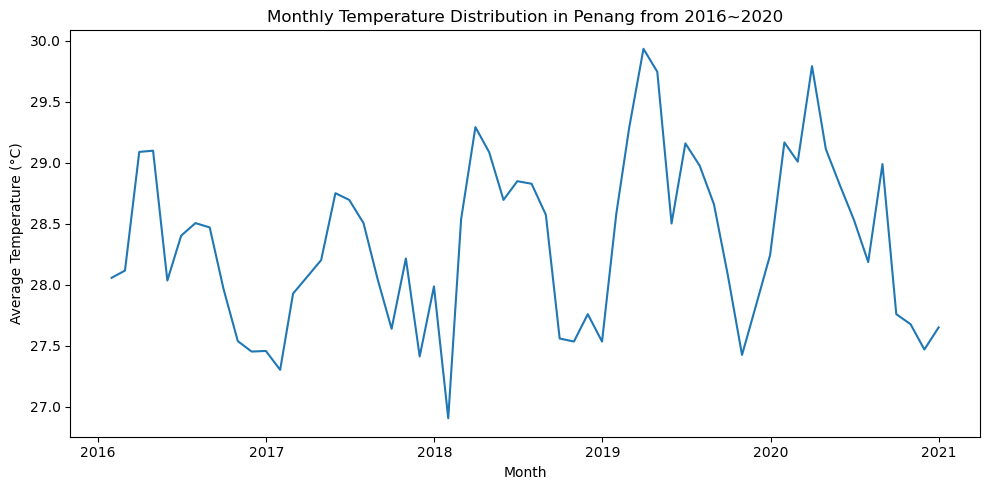

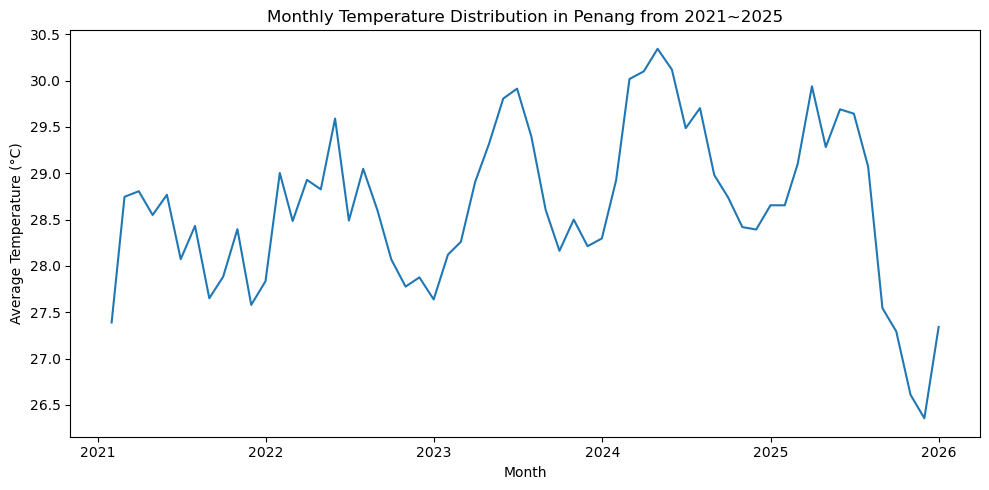

In [97]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset1)

plt.title("Monthly Temperature Distribution in Penang from 2010~2015")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset2)

plt.title("Monthly Temperature Distribution in Penang from 2016~2020")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset3)

plt.title("Monthly Temperature Distribution in Penang from 2021~2025")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()